# Results — everything recomputed

No caches. Every number on every figure is computed from scratch in this notebook, so nothing can
be stale. Expect roughly **20 minutes** for a full run.

What gets computed:

| series | data | starting point | fit |
|---|---|---|---|
| `fixed_no_fpr`, `fixed_fpr`, `adaptive_D`, `adaptive_A`, `adaptive_L`, `lm` | each run's own | — | reload `x_best.npy` and score |
| `adaptive_D + polish` | adaptive_D's shots, **revealed circuits only** | adaptive_D's parameters (warm) | logL MLE |
| `LM MLE (standalone)` | uniform over all circuits | ideal gates | logL MLE |

**Every series is fit on exactly the shots it is plotted at.** That is not automatic for the
polish. POUNDERS opens with a uniform baseline over all 1918 circuits, then FPR zeroes the
unselected residuals (`_apply_fpr_reduction`, with `rho_uses_full_objective=False`), so those
circuits never influence a step and the arm is billed only `accounted_revealed_shots`. Fitting
the polish on the full design would hand it the discarded baseline too — about 2x the shots on
its x-position, and data no other series gets. So the polish rebuilds the max-length ladder over
the union of FPR-selected circuits, read from `fpr_selection_history.csv`. At 1500/seed 101 that
is 652 circuits totalling 849,000 shots, matching the billed figure exactly.

`LM MLE (standalone)` touches no POUNDERS output at all. Its shot levels are derived from the
budgets on disk so it lines up with adaptive_D's totals.

**Every seed folder on disk** (`SEEDS = None`). An earlier version used only 101/102/103 to keep
budgets equally weighted, but that discarded real runs -- 800 has 11 seed folders and 3500 has 10.
The figures take a median per run folder, so unequal n only means some budgets' medians are better
estimated. At n=3 the 95% interval on a paired log-ratio spans about a factor of 2 either way,
wider than any effect here, so this is the change that matters most. Set `SEEDS = [101, 102, 103]`
to go back.

## Fits are saved, metrics are not

The two MLE passes are ~85% of the runtime, so each fitted parameter vector is written next to the
inputs it came from and reused on later runs:

```
all_methods_comparison_800/seed_000101/adaptive_D/
    x_best.npy            <- POUNDERS wrote this
    x_polished.npy        <- the polish, saved here
    x_polished_meta.json  <- what it was fit from
lm_standalone/seed000101_shots00264/
    x_best.npy  x_best_meta.json
```

Only the **parameter vector** is saved. Infidelity and diamond distance are recomputed from it
every run (~0.4s each), so the numbers on the figures always come from the current metric code and
a broken SDP environment can never write bad values to disk.

`*_meta.json` records a hash of every input — `x_best.npy`, `final_shots_per_circuit.npy`,
`config.json`, the data seed, and the optimiser settings. A saved fit is reused only if all of them
still match, so rerunning POUNDERS or changing `MAXITER` invalidates it automatically. Set
`REFIT = True` to force everything to refit regardless.

Diamond distance needs an SDP solver. Run the install cell below **once**, then **restart the
kernel** — pygsti decides whether cvxpy is available at import time, so installing it afterwards
has no effect until the kernel restarts. `cvxopt` is required too: cvxpy's default CLARABEL
backend fails on these problems and pygsti falls back to CVXOPT.

In [ ]:
# run once, then RESTART THE KERNEL (pygsti latches solver availability at import)
%pip install -q cvxpy cvxopt

In [49]:
import ast, hashlib, json, sys, time, warnings
from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DIR = Path.cwd()                       # run from seed_sweep_experiments
sys.path.insert(0, str(DIR))
warnings.filterwarnings("ignore")

import pygsti
from pygsti.protocols import (GST, GSTInitialModel, GSTObjFnBuilders, ProtocolData,
                              GateSetTomographyDesign)
from pygsti.optimize import SimplerLMOptimizer
from pygsti.tools import optools as _ot
from gst_seed_experiment import ExperimentConfig, GSTProblem

INF     = "mean_gate_entanglement_infidelity_to_truth"
MAXITER = 800

# None = every seed folder on disk; a list restricts to those seeds.
# Was [101, 102, 103] to keep budgets equally weighted, but that threw away real data: 800 has
# 11 seed folders and 3500 has 10. The plots take a median per run folder, so unequal n across
# budgets only means some medians are better estimated -- strictly better than discarding runs.
# At n=3 the 95% CI on a paired log-ratio spans roughly a factor of 2 either way, which is wider
# than any effect being measured here, so more seeds is the single highest-value change.
SEEDS = [101,102,103]

REFIT = False   # True forces every fit to rerun, ignoring what is saved on disk

# Fail immediately, and say why, rather than silently producing empty diamond values.
def _sdp_problem():
    try:
        import cvxpy
    except ImportError:
        return "cvxpy is not installed -- run the install cell above, then restart the kernel"
    sd = getattr(_ot, "_sdps", None)
    if sd is not None and not getattr(sd, "CVXPY_ENABLED", True):
        return (f"cvxpy {cvxpy.__version__} is installed but pygsti was imported before it "
                f"-- RESTART THE KERNEL")
    try:
        v = float(_ot.diamonddist(np.eye(4), np.diag([1.0, .999, .999, .999]), mx_basis="pp"))
    except Exception as exc:
        return (f"the SDP solve failed ({exc!r}) -- CLARABEL cannot handle these problems, so "
                f"install the fallback with `%pip install cvxopt` and restart the kernel")
    return None if np.isfinite(v) else "the SDP solver returned a non-finite value"

_bad = _sdp_problem()
if _bad:
    raise RuntimeError(f"no usable SDP solver: {_bad}")
print("SDP solver OK")

_probs = {}
def problem(cfg, seed):
    """GSTProblem is expensive to build, so reuse it across arms with the same truth/design."""
    k = (seed, cfg.truth_seed, cfg.model_kind, cfg.parameterization,
         cfg.noise_model, tuple(cfg.max_lengths))
    if k not in _probs:
        p = GSTProblem(cfg, seed)
        try:
            p.base_model.sim = "map"; p.truth_model.sim = "map"
        except Exception:
            pass
        _probs[k] = p
    return _probs[k]

def score(prob, mdl):
    """Gauge-optimised infidelity and mean diamond distance to truth."""
    summ, rows_, _ = prob.aligned_error_metrics(mdl, prob.truth_model, "truth")
    g = pd.DataFrame(rows_)
    g = g[g["reference"].astype(str).str.lower() == "truth"]
    dd = pd.to_numeric(g["diamond_distance"], errors="coerce")
    return float(summ[INF]), (float(dd.mean()) if dd.notna().any() else np.nan)

def mle(prob, data, start):
    """pyGSTi Levenberg-Marquardt on the Poisson-picture logL. Fits a FIXED dataset -- it never
    acquires more shots."""
    proto = GST(GSTInitialModel(start.copy()), gaugeopt_suite=None,
                objfn_builders=GSTObjFnBuilders.create_from("logl", always_perform_mle=True,
                                                            only_perform_mle=True),
                optimizer=SimplerLMOptimizer(maxiter=MAXITER, maxfev=MAXITER, tol=1e-6,
                                             init_munu="auto", oob_action="reject"),
                badfit_options=None, verbosity=0, name="f")
    return proto.run(data, disable_checkpointing=True).estimates["f"].models[
        "final iteration estimate"]

# A fit is saved as a parameter vector beside its inputs, together with a record of what it was
# fit from. It is reused only when every one of those inputs still hashes the same, so rerunning
# POUNDERS (new x_best.npy) or changing MAXITER silently invalidates it and it refits.
# Metrics are NEVER saved -- they are always recomputed from the vector, which costs ~0.4s and
# keeps a broken SDP environment from writing bad numbers to disk.
FIT_TAG = f"logl-mle|maxiter={MAXITER}|tol=1e-6|pygsti={pygsti.__version__}"

def _sha(p):
    return hashlib.sha256(Path(p).read_bytes()).hexdigest()[:16]

def cached_fit(out_dir, stem, inputs, fit):
    """Return (x, seconds, reused). Saves <stem>.npy and <stem>_meta.json in out_dir."""
    out_dir.mkdir(parents=True, exist_ok=True)
    npy, meta = out_dir / f"{stem}.npy", out_dir / f"{stem}_meta.json"
    if not REFIT and npy.exists() and meta.exists():
        m = json.loads(meta.read_text())
        if m.get("inputs") == inputs:
            return np.load(npy), m.get("seconds"), True
    t0 = time.time()
    x = np.asarray(fit().to_vector(), dtype=float)
    el = round(time.time() - t0, 1)
    np.save(npy, x)
    meta.write_text(json.dumps(dict(inputs=inputs, seconds=el, n_params=int(x.size),
                                    written=time.strftime("%Y-%m-%d %H:%M:%S")), indent=2))
    return x, el, False

def revealed_design(prob, arm_dir, vec):
    """The circuits POUNDERS actually used, and their shots.

    POUNDERS opens with a uniform baseline over ALL 1918 circuits, then FPR masks most of them
    out -- `_apply_fpr_reduction` sets the unselected residuals to zero, and
    `rho_uses_full_objective=False`, so those rows never touch the model or the accept/reject.
    The arm is therefore billed `accounted_revealed_shots`, which counts only the union of
    FPR-selected circuits.

    Fitting the polish on all 1918 would hand it the baseline shots on circuits POUNDERS threw
    away -- about twice the data it is plotted at. This rebuilds the max-length ladder over the
    revealed union only, so the polish consumes exactly its billed budget.

    Returns (design, circuits, shots) or None when the selection history is missing.
    """
    hist = arm_dir / "fpr_selection_history.csv"
    if not hist.exists():
        return None
    seen = set()
    for cell in pd.read_csv(hist)["selected_circuit_indices"].dropna():
        try:
            seen |= set(ast.literal_eval(cell))
        except (ValueError, SyntaxError):
            continue
    if not seen:
        return None
    keep = {prob.circuits[i] for i in sorted(seen)}
    # Keep the ladder nested: intersect each max-length stage with the revealed union.
    lists = [[c for c in stage if c in keep] for stage in prob.design.circuit_lists]
    if not lists or not lists[-1]:
        return None
    src = prob.processor_spec if prob.processor_spec is not None else prob.target_model
    design = GateSetTomographyDesign(src, lists)
    circuits = list(design.all_circuits_needing_data)
    at = {c: i for i, c in enumerate(prob.circuits)}
    return design, circuits, np.array([vec[at[c]] for c in circuits], dtype=int)

RUNS = [r for r in sorted(DIR.glob("all_methods_comparison*")) if r.is_dir()]

def seed_dirs(run):
    """The run's seed folders; all of them when SEEDS is None."""
    return [sd for sd in sorted(run.glob("seed_*"))
            if SEEDS is None or int(sd.name.split("_")[1]) in SEEDS]

for r in RUNS:
    print(f"{r.name}: using {len(seed_dirs(r))} of "
          f"{len(list(r.glob('seed_*')))} seed folders")

SDP solver OK
all_methods_comparison_1500: using 3 of 3 seed folders
all_methods_comparison_2000: using 3 of 3 seed folders
all_methods_comparison_2500: using 3 of 5 seed folders
all_methods_comparison_3500: using 3 of 10 seed folders
all_methods_comparison_500: using 3 of 3 seed folders
all_methods_comparison_800: using 3 of 11 seed folders
all_methods_comparison_withLM2500: using 3 of 5 seed folders


## Compute

In [50]:
t_start = time.time()
rows, n_reused = [], 0

# ---- 1. every arm in every run folder: reload x_best and score it -------------------------
for run in RUNS:
    for sd in seed_dirs(run):
        for arm_dir in sorted(p for p in sd.iterdir() if p.is_dir()):
            need = ["x_best.npy", "config.json", "problem_metadata.json", "summary.json"]
            if not all((arm_dir / f).exists() for f in need):
                continue
            cfg = replace(ExperimentConfig.from_json(arm_dir / "config.json"),
                          report_diamond_distance=True)
            seed = int(json.loads((arm_dir / "problem_metadata.json").read_text())["data_seed"])
            prob = problem(cfg, seed)
            inf, dd = score(prob, prob.copy_model_at_x(np.load(arm_dir / "x_best.npy")))
            rows.append(dict(run=run.name, seed=seed, method=arm_dir.name,
                             shots=float(json.loads((arm_dir / "summary.json").read_text())
                                         ["accounted_revealed_shots"]),
                             infidelity=inf, diamond=dd))
print(f"scored {len(rows)} runs   [{time.time()-t_start:.0f}s]")

# ---- 2. adaptive_D warm-started into the LM MLE, on adaptive_D's own shots ------------------
for run in RUNS:
    for sd in seed_dirs(run):
        ad = sd / "adaptive_D"
        need = ["x_best.npy", "config.json", "problem_metadata.json",
                "final_shots_per_circuit.npy", "summary.json"]
        if not all((ad / f).exists() for f in need):
            continue
        cfg = replace(ExperimentConfig.from_json(ad / "config.json"),
                      report_diamond_distance=True)
        seed = int(json.loads((ad / "problem_metadata.json").read_text())["data_seed"])
        prob = problem(cfg, seed)
        vec = np.load(ad / "final_shots_per_circuit.npy").astype(int)
        # Restrict to the circuits POUNDERS actually used. Without this the polish would also
        # see the baseline shots on the ~1266 circuits FPR never selected -- roughly twice the
        # shots this point is plotted at, and data no other series on the figure receives.
        rev = revealed_design(prob, ad, vec)
        if rev is None:
            print(f"  SKIP {run.name}/{sd.name}: no usable fpr_selection_history.csv, so the "
                  f"revealed circuit set cannot be reconstructed")
            continue
        design_rev, circs_rev, shots_rev = rev
        # Draw at the arm's own data seed rather than an offset one.
        #
        # This does NOT reproduce adaptive_D's actual measurement outcomes -- those were never
        # saved. POUNDERS built its dataset incrementally (set_uniform_dataset at the baseline,
        # then ~300 rounds of top-ups) and only the final per-circuit counts survive in
        # final_shots_per_circuit.npy. What this does is stop the polish from being a
        # deliberately INDEPENDENT realisation: it was drawing at 9_500_000 + seed, which made
        # polish-vs-adaptive_D a comparison of two different datasets rather than two estimators.
        # Sharing the seed leaves the two partially correlated instead of independent.
        #
        # The honest fix is upstream: have gst_seed_experiment.py save the final dataset so the
        # polish can fit the outcomes POUNDERS actually measured. That needs a POUNDERS rerun.
        dseed = seed
        inputs = dict(x_best=_sha(ad / "x_best.npy"),
                      shots=_sha(ad / "final_shots_per_circuit.npy"),
                      cfg=_sha(ad / "config.json"), dseed=dseed, fit=FIT_TAG,
                      circuits="revealed", hist=_sha(ad / "fpr_selection_history.csv"),
                      n_circuits=len(circs_rev), n_shots=int(shots_rev.sum()))
        # x_polished.npy lands next to x_best.npy, as an artifact of the run it belongs to
        x_pol, el, reused = cached_fit(
            ad, "x_polished", inputs,
            lambda: mle(prob, ProtocolData(design_rev,
                                           prob.simulate_dataset(shots_rev, seed=dseed,
                                                                 circuits=circs_rev)),
                        prob.copy_model_at_x(np.load(ad / "x_best.npy"))))
        # scored from the vector on both paths, so a reused fit and a fresh one agree exactly
        inf, dd = score(prob, prob.copy_model_at_x(x_pol))
        n_reused += reused
        billed = float(json.loads((ad / "summary.json").read_text())["accounted_revealed_shots"])
        if int(shots_rev.sum()) != int(billed):
            print(f"    note: used {shots_rev.sum():,} shots vs {billed:,.0f} billed")
        print(f"  {'reused ' if reused else 'fitted '} {run.name}/{sd.name}  "
              f"{len(circs_rev)} circuits, {shots_rev.sum():>9,} shots   "
              f"infid {inf:.4e}  diamond {dd:.4e}  ({el}s)")
        # plotted at what it actually consumed, which now equals what the arm was billed
        rows.append(dict(run=run.name, seed=seed, method="adaptive_D + polish",
                         shots=float(shots_rev.sum()), infidelity=inf, diamond=dd))
print(f"polish done   [{time.time()-t_start:.0f}s]")

# ---- 3. LM MLE standalone: uniform circuits, ideal gates, no POUNDERS input -----------------
# Budget is EACH SEED's own accounted_revealed_shots, not a median over seeds. The median cost
# up to 9% per-seed mismatch against adaptive_D, which broke seed-level pairing even though the
# folder medians lined up.
cfg0 = replace(ExperimentConfig.from_json(DIR / "experiment_config.json"),
               report_diamond_distance=True)
# These have no run folder of their own, so they get one: lm_standalone/seed<s>_shots<n>/
# Two run folders that land on the same (seed, level) share a fit, which is correct -- the fit
# depends only on the seed, the level, cfg0 and FIT_TAG, so it is the same estimate either way.
for run in RUNS:
    for sd in seed_dirs(run):
        f = sd / "adaptive_D" / "summary.json"
        if not f.exists():
            continue
        s_ = json.loads(f.read_text())
        ncirc = int(s_.get("total_circuits") or 1918)
        seed = int(sd.name.split("_")[1])
        shots = max(1, int(round(float(s_["accounted_revealed_shots"]) / ncirc)))
        prob = problem(cfg0, seed)
        vec = prob.normalize_shots(shots)
        out = DIR / "lm_standalone" / f"seed{seed:06d}_shots{shots:05d}"
        inputs = dict(cfg=_sha(DIR / "experiment_config.json"), seed=seed, shots=int(shots),
                      total=int(vec.sum()), fit=FIT_TAG)
        x_sa, el, reused = cached_fit(
            out, "x_best", inputs,
            lambda: mle(prob, ProtocolData(prob.design,
                                           prob.simulate_dataset(vec, seed=seed)),
                        prob.copy_model_at_x(np.zeros(prob.n))))
        inf, dd = score(prob, prob.copy_model_at_x(x_sa))
        n_reused += reused
        print(f"  {'reused ' if reused else 'fitted '} {run.name}/{sd.name}  "
              f"{shots:>5} sh/circ x {ncirc} = {vec.sum():>9,} shots "
              f"(target {float(s_['accounted_revealed_shots']):>9,.0f})   "
              f"infid {inf:.4e}  diamond {dd:.4e}  ({el}s)")
        # run=run.name so these share the plot's x-groups with every other arm
        rows.append(dict(run=run.name, seed=seed, method="LM MLE (standalone)",
                         shots=float(vec.sum()), infidelity=inf, diamond=dd))

df = pd.DataFrame(rows)
n_fits = int(df["method"].isin(["adaptive_D + polish", "LM MLE (standalone)"]).sum())
print(f"TOTAL {len(df)} results in {time.time()-t_start:.0f}s "
      f"({n_reused}/{n_fits} fits reused from disk)")
print()
print(df.groupby("method").agg(runs=("seed", "size"), seeds=("seed", "nunique"),
                               budgets=("run", "nunique"),
                               with_diamond=("diamond", lambda v: v.notna().sum())).to_string())

scored 85 runs   [42s]
  reused  all_methods_comparison_1500/seed_000101  652 circuits,   849,000 shots   infid 5.7260e-05  diamond 1.0880e-03  (57.0s)
    note: used 948,550 shots vs 937,500 billed
  reused  all_methods_comparison_1500/seed_000102  633 circuits,   948,550 shots   infid 6.6803e-05  diamond 1.0177e-03  (52.5s)
  reused  all_methods_comparison_1500/seed_000103  660 circuits,   862,500 shots   infid 7.5182e-05  diamond 1.5208e-03  (57.9s)
    note: used 1,141,000 shots vs 1,132,000 billed
  reused  all_methods_comparison_2000/seed_000101  662 circuits, 1,141,000 shots   infid 8.1454e-05  diamond 1.3662e-03  (80.5s)
  reused  all_methods_comparison_2000/seed_000102  672 circuits, 1,034,000 shots   infid 1.4341e-04  diamond 1.4111e-03  (85.2s)
  reused  all_methods_comparison_2000/seed_000103  671 circuits, 1,216,000 shots   infid 5.4584e-05  diamond 1.0810e-03  (107.6s)
  reused  all_methods_comparison_2500/seed_000101  667 circuits, 1,265,000 shots   infid 2.3200e-05  dia

## LM on a pyGSTi built-in FPR design

The missing cell of the 2x2. Every other arm either uses the full 1918-circuit design (`lm`,
`LM MLE (standalone)`, `fixed_no_fpr`) or uses **our own** online FPR inside POUNDERS
(`fixed_fpr`, `adaptive_D`). Nothing so far runs LM on an FPR-reduced design, so a gap between
`fixed_fpr` and `lm` cannot be attributed to the optimiser or to the design — both change at once.

This cell closes that. It calls pyGSTi's own
`find_sufficient_fiducial_pairs_per_germ_greedy`, builds a `StandardGSTDesign` from the returned
pair set, simulates data on that reduced circuit list **at the same total shot budget** as the
standalone arm, and runs the identical `mle()` used everywhere else. So the only thing that
differs from `LM MLE (standalone)` is the design.

### Budget

Each fit is matched to **its own run folder and its own seed**, reading
`accounted_revealed_shots` straight out of `<run>/<seed>/adaptive_D/summary.json` rather than from
a median-derived level. So the LM+FPR point in `all_methods_comparison_1500` at seed 101 spends
exactly what adaptive_D spent there — not the median across seeds.

That budget is the **revealed** shot count: the shots actually charged on the x-axis, the same
quantity every other series is plotted against. `adaptive_D` and `fixed_fpr` carry byte-identical
values for it in every folder, so `BUDGET_FROM` makes no practical difference.

The total is spread uniformly over the reduced circuit list, so each surviving circuit gets
proportionally more shots than it would in the full design — that is the point of FPR.

### Where pairs are selected

`FPR_AT` controls which model the pairs are selected at:

- `"target"` — the ideal gates. This is the standard pyGSTi workflow and what
  [arXiv:2308.08781](https://arxiv.org/abs/2308.08781) does (selection at theta -> 0). Every run
  folder shares one pair set, since they all share the target model and max_lengths.
- `"adaptive_D"` — the POUNDERS estimate for that seed, i.e. selection at an *informed* model.
  Re-solves per seed.

The difference between those two settings is a direct measurement of how much the
"select at the target and hope truth is close" assumption costs.

### Where results are stored

Beside the arm they are matched to, as `<run>/<seed>/lm_fpr/x_best_<FPR_AT>_<basis>.npy` plus a
`_meta.json` recording the budget, the basis, the circuit count, and hashes of the config and
summary it was derived from. The folder deliberately contains **no** `config.json` /
`problem_metadata.json` / `summary.json`, and the vectors are not named plain `x_best.npy`, so
pass 1 of the compute cell skips it and cannot double-count these as another POUNDERS arm.

Two diagnostics print before the fits: how many circuits survive, and how many parameters the
pair set amplifies — always **reduced against the full 360-pair set at the same model**, since
the absolute count from `test_fiducial_pairs` is not "parameters identified" (the full set scores
the same 9 as the reduced set on this gate set). Equal counts mean the reduction cost no
amplification.

The second test evaluates at adaptive_D's estimate rather than the target, standing in for "a
realistic model that is not where the pairs were chosen." It deliberately does not use the truth
model, which carries a different parameterisation and therefore a non-comparable parameter count.
If the count holds up away from the selection point, amplificational completeness transfers and
only *conditioning* is at stake — a shot-count penalty, not a failure to identify.

In [51]:
from pygsti.algorithms.fiducialpairreduction import (
    find_sufficient_fiducial_pairs_per_germ_greedy, test_fiducial_pairs)
from pygsti.protocols import StandardGSTDesign

FPR_AT        = "target"        # "target" | "adaptive_D" -- which model the pairs are chosen at
BUDGET_FROM   = "adaptive_D"    # whose budget to match, per run folder and per seed
BUDGET_KEY    = "accounted_revealed_shots"   # revealed shots only -- the x-axis everything uses
INV_TRACE_TOL = 10              # A-optimality slack the greedy search accepts vs the full set
FPR_SEED      = 2024            # the greedy search seeds itself randomly; pin it so runs reproduce
METH          = "LM + FPR"

t_fpr = time.time()

def fpr_pairs(prob, x, tag):
    """pyGSTi per-germ greedy FPR at the model `x`. Cached: the solve is deterministic given
    (x, tolerance, seed, pygsti version), and it is slow enough to be worth not repeating."""
    germs = list(prob.germs)
    out = DIR / "fpr_builtin"; out.mkdir(parents=True, exist_ok=True)
    f = out / f"pairs_{tag}.json"
    key = dict(x=hashlib.sha256(np.ascontiguousarray(np.asarray(x, float)).tobytes()).hexdigest()[:16],
               tol=INV_TRACE_TOL, seed=FPR_SEED, ngerms=len(germs),
               nprep=len(prob.prep_fiducials), nmeas=len(prob.meas_fiducials),
               pygsti=pygsti.__version__)
    if not REFIT and f.exists():
        blob = json.loads(f.read_text())
        if blob.get("key") == key:
            return ({germs[int(i)]: [tuple(p) for p in v] for i, v in blob["pairs"].items()},
                    blob["seconds"], True)
    t0 = time.time()
    pairs = find_sufficient_fiducial_pairs_per_germ_greedy(
        prob.copy_model_at_x(x), prob.prep_fiducials, prob.meas_fiducials, germs,
        constrain_to_tp=True, inv_trace_tol=INV_TRACE_TOL, seed=FPR_SEED, verbosity=0)
    el = round(time.time() - t0, 1)
    f.write_text(json.dumps(dict(key=key, seconds=el, pairs={
        str(i): [[int(a), int(b)] for a, b in pairs.get(g, [])] for i, g in enumerate(germs)}),
        indent=2))
    return pairs, el, False

def fpr_design(prob, cfg, pairs):
    """The same StandardGSTDesign as prob.design, minus the fiducial pairs FPR dropped."""
    src = prob.processor_spec if prob.processor_spec is not None else prob.target_model
    d = StandardGSTDesign(src, prob.prep_fiducials, prob.meas_fiducials, list(prob.germs),
                          list(cfg.max_lengths), fiducial_pairs=pairs)
    return d, list(d.all_circuits_needing_data)

def full_pairs(prob):
    """Every (prep, meas) pair for every germ -- the unreduced reference set."""
    ij = [(i, j) for i in range(len(prob.prep_fiducials))
                 for j in range(len(prob.meas_fiducials))]
    return {g: list(ij) for g in prob.germs}

def amplified(prob, pairs, x, what):
    """Parameters the pair set amplifies at model `x`, REPORTED AGAINST THE FULL SET.

    The absolute number `test_fiducial_pairs` returns is not "how many of the 72 model
    parameters are identified" -- the full 360-pair set scores the same 9 as the reduced set
    here. Only reduced-vs-full is meaningful: equal means the reduction cost no amplification.

    Both call sites pass a vector in the same CPTPLND parameterisation, so the numbers compare.
    Do not pass prob.truth_model -- it is parameterised differently and its count would not
    mean the same thing."""
    mdl = prob.copy_model_at_x(x)
    try:
        kw = dict(verbosity=0)
        n = int(test_fiducial_pairs(pairs, mdl, prob.prep_fiducials, prob.meas_fiducials,
                                    list(prob.germs), **kw))
        ref = int(test_fiducial_pairs(full_pairs(prob), mdl, prob.prep_fiducials,
                                      prob.meas_fiducials, list(prob.germs), **kw))
        flag = "ok" if n >= ref else f"LOST {ref - n}"
        print(f"    amplified at {what}: reduced {n} vs full {ref}   [{flag}]")
        return n, ref
    except Exception as exc:
        print(f"    (amplification test at {what} unavailable: {exc!r})")
        return None, None

def adaptive_D_x(seed):
    """That seed's adaptive_D estimate, from the largest budget it appears in."""
    best = None
    for run in RUNS:
        for sd in seed_dirs(run):
            if int(sd.name.split("_")[1]) != seed:
                continue
            s_, xb = sd / "adaptive_D" / "summary.json", sd / "adaptive_D" / "x_best.npy"
            if s_.exists() and xb.exists():
                tot = float(json.loads(s_.read_text())["accounted_revealed_shots"])
                if best is None or tot > best[0]:
                    best = (tot, xb)
    if best is None:
        raise FileNotFoundError(f"no adaptive_D/x_best.npy for seed {seed}")
    return np.load(best[1])

# The FPR solve and the reduced design are cached in-process. With FPR_AT="target" every run
# folder shares one of each (same target model, same max_lengths everywhere); with "adaptive_D"
# there is one per seed. Keyed on max_lengths too, so a folder with a different ladder gets its
# own design instead of silently reusing another one.
_designs = {}
def design_for(prob, cfg, seed):
    tag, x = (("target", prob.x0) if FPR_AT == "target"
              else (f"adaptiveD_seed{seed:06d}", adaptive_D_x(seed)))
    key = (tag, tuple(cfg.max_lengths))
    if key not in _designs:
        pairs, el, reused = fpr_pairs(prob, x, tag)
        d, circs = fpr_design(prob, cfg, pairs)
        n_full = len(prob.circuits)
        print(f"FPR[{tag}] maxL={list(cfg.max_lengths)}: {'reused' if reused else 'solved'} "
              f"({el}s) -> {sum(len(v) for v in pairs.values())} pairs over {len(prob.germs)} "
              f"germs, {len(circs)} of {n_full} circuits ({100*len(circs)/n_full:.1f}%)")
        # Chosen at one model, used at another. adaptive_D's estimate stands in for "a realistic
        # model that is not the target"; truth itself is parameterised differently, so its
        # parameter count would not be comparable.
        amplified(prob, pairs, prob.x0, "the target")
        try:
            amplified(prob, pairs, adaptive_D_x(seed), "the adaptive_D estimate")
        except FileNotFoundError:
            pass
        _designs[key] = (pairs, d, circs)
    return _designs[key]

new_rows = []
for run in RUNS:
    for sd in seed_dirs(run):
        src = sd / BUDGET_FROM
        need = ["config.json", "problem_metadata.json", "summary.json"]
        if not all((src / f).exists() for f in need):
            continue
        cfg = replace(ExperimentConfig.from_json(src / "config.json"),
                      report_diamond_distance=True)
        seed = int(json.loads((src / "problem_metadata.json").read_text())["data_seed"])
        prob = problem(cfg, seed)
        summ = json.loads((src / "summary.json").read_text())
        pairs, design_fpr, circs = design_for(prob, cfg, seed)

        # This seed's own revealed-shot budget in this folder -- not a median over seeds.
        budget = int(round(float(summ[BUDGET_KEY])))
        # Same total, fewer circuits, so each surviving circuit gets proportionally more.
        per = max(1, int(round(budget / len(circs))))
        vec = np.full(len(circs), per, dtype=int)
        # Lands beside adaptive_D. No config/summary here and the vector is not called
        # x_best.npy, so pass 1 of the compute cell cannot mistake it for a POUNDERS arm.
        # The "_accounted" suffix records which budget it was fit at and keeps fits written
        # by earlier versions of this cell valid.
        x_f, el, reu = cached_fit(
            sd / "lm_fpr", f"x_best_{FPR_AT}_accounted",
            dict(cfg=_sha(src / "config.json"), summary=_sha(src / "summary.json"),
                 seed=seed, basis="accounted", budget=budget, budget_from=BUDGET_FROM,
                 per_circuit=int(per), ncirc=len(circs), realised=int(vec.sum()),
                 fpr_at=FPR_AT, tol=INV_TRACE_TOL, fpr_seed=FPR_SEED, fit=FIT_TAG),
            lambda: mle(prob,
                        ProtocolData(design_fpr,
                                     prob.simulate_dataset(vec, seed=seed, circuits=circs)),
                        prob.copy_model_at_x(np.zeros(prob.n))))
        inf, dd = score(prob, prob.copy_model_at_x(x_f))
        print(f"  {'reused ' if reu else 'fitted '} {run.name}/{sd.name}  "
              f"budget {budget:>9,} -> {per:>6,} sh/circ x {len(circs)} = {vec.sum():>9,}   "
              f"infid {inf:.4e}  diamond {dd:.4e}  ({el}s)")
        # run=run.name so these share the plot's x-groups with every other arm.
        new_rows.append(dict(run=run.name, seed=seed, method=METH,
                             shots=float(vec.sum()), infidelity=inf, diamond=dd))

# Idempotent: drop any earlier rows for this method so re-running cannot duplicate them.
df = pd.concat([df[df["method"] != METH], pd.DataFrame(new_rows)], ignore_index=True)
print(f"\n{METH}: {len(new_rows)} results in {time.time()-t_fpr:.0f}s "
      f"(FPR_AT={FPR_AT!r}, budget from {BUDGET_FROM!r}/{BUDGET_KEY})")

FPR[target] maxL=[1, 2, 4, 8, 16, 32, 64]: reused (0.6s) -> 60 pairs over 10 germs, 440 of 1918 circuits (22.9%)
    amplified at the target: reduced 9 vs full 9   [ok]
    amplified at the adaptive_D estimate: reduced 3 vs full 3   [ok]
  reused  all_methods_comparison_1500/seed_000101  budget   849,000 ->  1,930 sh/circ x 440 =   849,200   infid 1.0214e-04  diamond 1.8367e-03  (102.7s)
  reused  all_methods_comparison_1500/seed_000102  budget   937,500 ->  2,131 sh/circ x 440 =   937,640   infid 1.4441e-04  diamond 1.5932e-03  (60.0s)
  reused  all_methods_comparison_1500/seed_000103  budget   862,500 ->  1,960 sh/circ x 440 =   862,400   infid 1.1092e-04  diamond 1.2829e-03  (157.9s)
  reused  all_methods_comparison_2000/seed_000101  budget 1,132,000 ->  2,573 sh/circ x 440 = 1,132,120   infid 1.3359e-04  diamond 1.5991e-03  (50.5s)
  reused  all_methods_comparison_2000/seed_000102  budget 1,034,000 ->  2,350 sh/circ x 440 = 1,034,000   infid 5.9650e-05  diamond 1.2851e-03  (91.6s)


## Plots

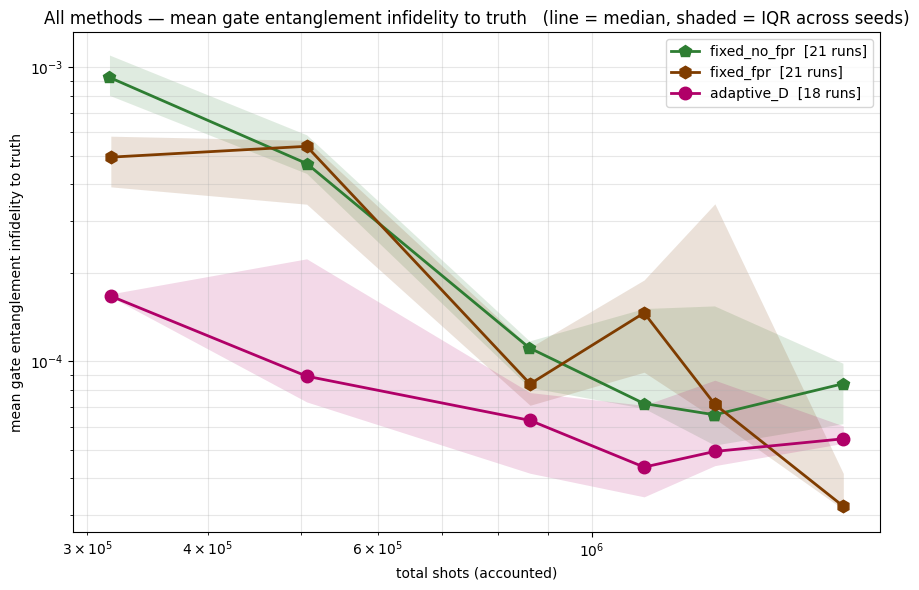

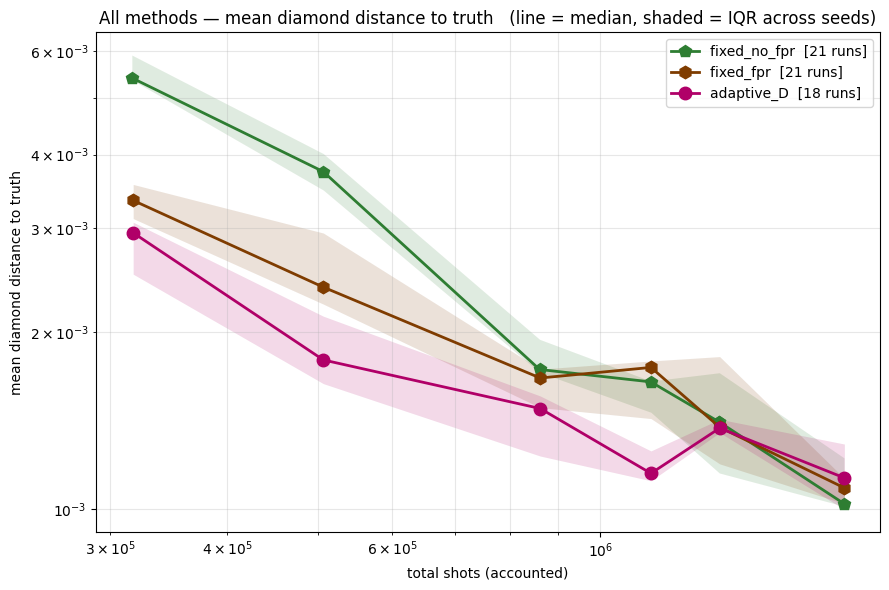

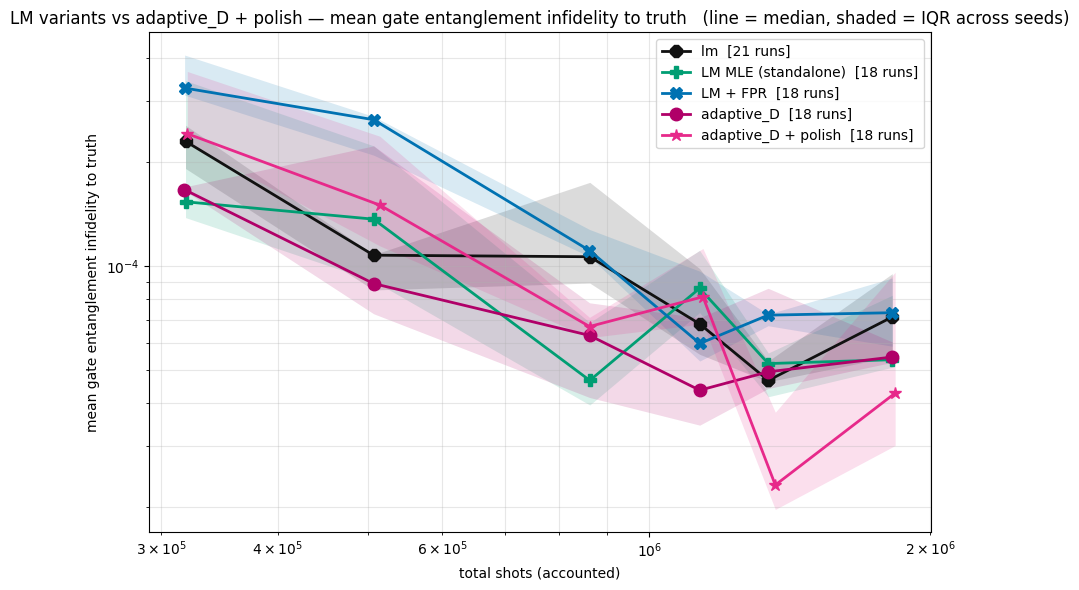

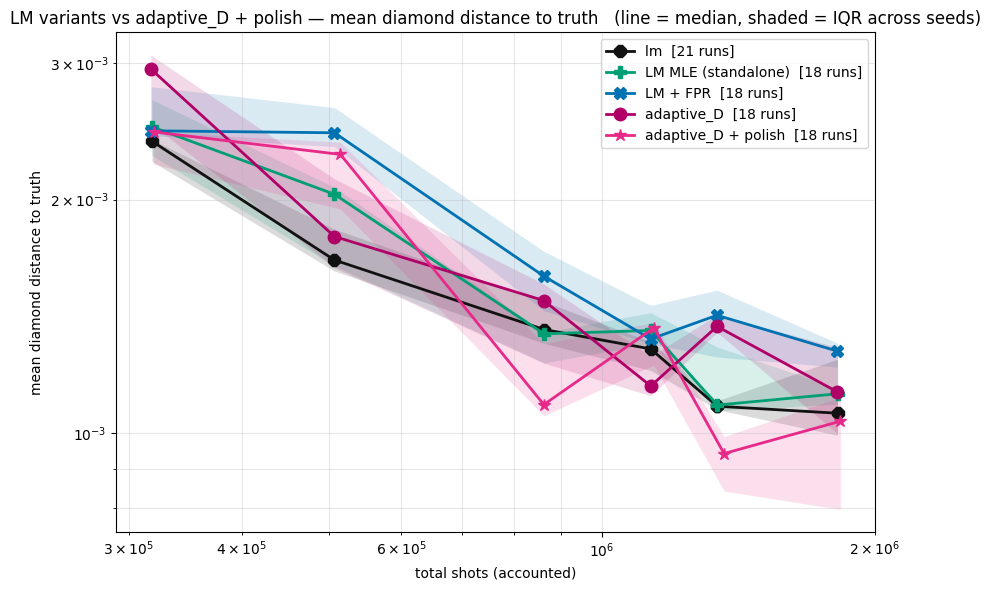

figures written to /workspace/IBCDFO/GST_POUNDERS/seed_sweep_experiments


In [54]:
STYLE = {"fixed_no_fpr": ("#2E7D32", "p"), "fixed_fpr": ("#7F3C00", "h"),
         "adaptive_D": ("#B00068", "o"), "adaptive_A": ("#56B4E9", "D"),
         "adaptive_L": ("#CC79A7", "v"), "lm": ("#111111", "8"),
         "adaptive_D + polish": ("#E7298A", "*"), "LM MLE (standalone)": ("#009E73", "P"),
         "LM + FPR": ("#0072B2", "X")}
METRICS = (("infidelity", "mean gate entanglement infidelity to truth"),
           ("diamond",    "mean diamond distance to truth"))

# Spread around the median, computed across the seeds within each run folder.
#   "iqr"  - shaded 25th-75th percentile band (readable with several series overlapping)
#   "bars" - capped error bars at the same quartiles
#   "none" - median line only
# The quartiles are over as few as 3 seeds at some budgets, so treat a narrow band as
# "not many runs" rather than "precise". The legend carries the count per series.
SPREAD = "iqr"

def plot(methods, title, prefix):
    for metric, ylabel in METRICS:
        fig, ax = plt.subplots(figsize=(9, 6))
        drawn = False
        for m in methods:
            a = df[df["method"] == m].dropna(subset=[metric])
            if a.empty:
                continue
            g = (a.groupby("run").agg(x=("shots", "median"), y=(metric, "median"),
                                      lo=(metric, lambda v: v.quantile(0.25)),
                                      hi=(metric, lambda v: v.quantile(0.75)),
                                      n=("seed", "nunique")).sort_values("x"))
            c, mk = STYLE.get(m, ("grey", "o"))
            if SPREAD == "iqr":
                ax.fill_between(g["x"], g["lo"], g["hi"], color=c, alpha=0.15, lw=0)
            elif SPREAD == "bars":
                ax.errorbar(g["x"], g["y"],
                            yerr=np.vstack([(g["y"] - g["lo"]).values,
                                            (g["hi"] - g["y"]).values]),
                            fmt="none", ecolor=c, elinewidth=1.2, capsize=4, alpha=0.75)
            ax.plot(g["x"], g["y"], color=c, marker=mk, ms=9, lw=2,
                    label=f"{m}  [{int(g['n'].sum())} runs]")
            drawn = True
        if not drawn:
            plt.close(fig); continue
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("total shots (accounted)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title} — {ylabel}"
                     + ("   (line = median, shaded = IQR across seeds)" if SPREAD == "iqr"
                        else "   (line = median, bars = IQR across seeds)" if SPREAD == "bars"
                        else "   (median across seeds)"))
        ax.grid(alpha=0.3, which="both")
        ax.legend()
        fig.tight_layout()
        fig.savefig(DIR / f"{prefix}_{metric}.png", dpi=150, bbox_inches="tight")
        plt.show()

# 1. the run folders, plus the polished adaptive_D. adaptive_A and adaptive_L are still
# computed and sit in `df`, they are just not drawn.
plot(["fixed_no_fpr", "fixed_fpr", "adaptive_D"],
     "All methods", "all")

# 2. every LM baseline vs the warm-started POUNDERS pipeline, all at matched revealed shots.
#    lm                  = pyGSTi defaults: chi2 up the max-length ladder, one dlogl at the end
#    LM MLE (standalone) = dlogl at every ladder stage, no chi2 warmup, full 1918-circuit design
#    LM + FPR            = same dlogl fit on pyGSTi's static FPR design (440 circuits, more
#                          shots each) -- isolates the design, since the estimator matches
#                          LM MLE (standalone) exactly
#    adaptive_D + polish = POUNDERS with our online FPR and adaptive allocation, then that
#                          same dlogl fit
plot(["lm", "LM MLE (standalone)", "LM + FPR", "adaptive_D", "adaptive_D + polish"],
     "LM variants vs adaptive_D + polish", "cmp")

# 3. the POUNDERS pipeline, step by step
# plot(["fixed_no_fpr", "fixed_fpr", "adaptive_D"],
#      "POUNDERS pipeline", "pounders")

print("figures written to", DIR)

## SPAM error

Read straight off disk — no refitting, no re-scoring, no pyGSTi call. Two sources, both written
at run time by `gst_seed_experiment.py`:

| arm | where SPAM comes from |
|---|---|
| `fixed_no_fpr`, `fixed_fpr`, `adaptive_D` | `summary.json` → `mean_spam_vector_l2_error_to_truth` |
| `lm` | last row of `lm_trajectory.csv` |
| `adaptive_D + polish`, `LM MLE (standalone)`, `LM + FPR` | **nothing stored** — notebook-computed, no `summary.json` or trajectory, so they are absent |

`lm` never got the SPAM field written into its `summary.json`, but it does write
`lm_trajectory.csv` with one row per max-length stage and a SPAM column. The **last** row is the
final estimate: its infidelity matches `summary.json` exactly on all 34 seed folders, so its SPAM
is `x_best`'s SPAM. The cell re-checks that match per seed and skips any folder where it fails,
rather than assuming.

The stored POUNDERS values were also checked against a fresh `aligned_error_metrics` call — ratio
1.000 on every arm and budget — so reading is equivalent to recomputing, just instant.

Independent of `df`: it builds its own `spam_df` from disk, runs in a couple of seconds, and does
not need the compute cells above to have run.

              runs  seeds  budgets
method                            
adaptive_D      18      3        6
fixed_fpr       21      3        7
fixed_no_fpr    21      3        7
lm              21      3        7

median SPAM error by budget
method                             fixed_no_fpr  fixed_fpr  adaptive_D        lm
run                                                                             
all_methods_comparison_1500           1.713e-03  2.739e-03   2.412e-03 1.652e-03
all_methods_comparison_2000           1.564e-03  1.256e-03   1.972e-03 1.509e-03
all_methods_comparison_2500           2.098e-03  1.381e-03   2.531e-03 1.268e-03
all_methods_comparison_3500           1.357e-03  1.012e-03   1.744e-03 1.103e-03
all_methods_comparison_500            5.608e-03  4.302e-03   4.879e-03 2.512e-03
all_methods_comparison_800            3.196e-03  2.434e-03   1.924e-03 1.976e-03
all_methods_comparison_withLM2500     2.098e-03  1.381e-03         NaN 1.268e-03


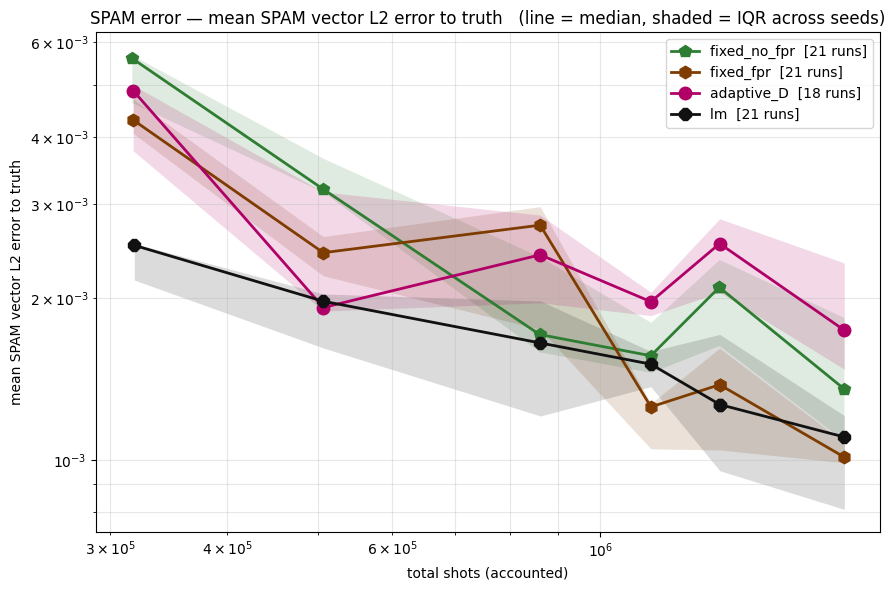

figure written to /workspace/IBCDFO/GST_POUNDERS/seed_sweep_experiments/spam_spam.png


In [53]:
SPAM_KEY = "mean_spam_vector_l2_error_to_truth"
INF_KEY  = "mean_gate_entanglement_infidelity_to_truth"
# The POUNDERS arms store SPAM in summary.json. `lm` does not -- but it writes
# lm_trajectory.csv, one row per max-length stage, and the LAST row IS the final estimate: its
# infidelity matches summary.json exactly on all 34 seed folders, so its SPAM is x_best's SPAM.
# Either way nothing is recomputed. The notebook-computed arms (adaptive_D + polish,
# LM MLE (standalone), LM + FPR) have neither file, so they are deliberately absent.
SPAM_METHODS = ["fixed_no_fpr", "fixed_fpr", "adaptive_D", "lm"]

spam_rows = []
for run in RUNS:
    for sd in seed_dirs(run):
        for arm in SPAM_METHODS:
            f = sd / arm / "summary.json"
            if not f.exists():
                continue
            s = json.loads(f.read_text())
            if SPAM_KEY in s:
                val = float(s[SPAM_KEY])
            else:
                traj = sd / arm / "lm_trajectory.csv"
                if not traj.exists():
                    continue
                t = pd.read_csv(traj)
                if SPAM_KEY not in t.columns or t.empty:
                    continue
                last = t.iloc[-1]
                # only trust the trajectory when its final row really is the saved estimate
                if INF_KEY in t.columns and INF_KEY in s:
                    if abs(last[INF_KEY] - s[INF_KEY]) > 1e-9 * max(abs(s[INF_KEY]), 1e-30):
                        print(f"  skip {run.name}/{sd.name}/{arm}: last row of "
                              f"lm_trajectory.csv is not the final estimate")
                        continue
                val = float(last[SPAM_KEY])
            spam_rows.append(dict(run=run.name, seed=int(sd.name.split("_")[1]), method=arm,
                                  shots=float(s["accounted_revealed_shots"]), spam=val))

spam_df = pd.DataFrame(spam_rows)
print(spam_df.groupby("method").agg(runs=("seed", "size"), seeds=("seed", "nunique"),
                                    budgets=("run", "nunique")).to_string())
print()
print("median SPAM error by budget")
print(spam_df.pivot_table(index="run", columns="method", values="spam", aggfunc="median")
             .reindex(columns=SPAM_METHODS).to_string(float_format=lambda v: f"{v:.3e}"))

# SPREAD comes from the plots cell; default to "iqr" so this cell still stands alone
_spread = globals().get("SPREAD", "iqr")
fig, ax = plt.subplots(figsize=(9, 6))
for m in SPAM_METHODS:
    a = spam_df[spam_df["method"] == m].dropna(subset=["spam"])
    if a.empty:
        continue
    # same grouping as plot(): one point per run folder, median across that folder's seeds
    g = (a.groupby("run").agg(x=("shots", "median"), y=("spam", "median"),
                              lo=("spam", lambda v: v.quantile(0.25)),
                              hi=("spam", lambda v: v.quantile(0.75)),
                              n=("seed", "nunique")).sort_values("x"))
    c, mk = STYLE.get(m, ("grey", "o"))
    if _spread == "iqr":
        ax.fill_between(g["x"], g["lo"], g["hi"], color=c, alpha=0.15, lw=0)
    elif _spread == "bars":
        ax.errorbar(g["x"], g["y"],
                    yerr=np.vstack([(g["y"] - g["lo"]).values, (g["hi"] - g["y"]).values]),
                    fmt="none", ecolor=c, elinewidth=1.2, capsize=4, alpha=0.75)
    ax.plot(g["x"], g["y"], color=c, marker=mk, ms=9, lw=2,
            label=f"{m}  [{int(g['n'].sum())} runs]")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("total shots (accounted)")
ax.set_ylabel("mean SPAM vector L2 error to truth")
ax.set_title("SPAM error — mean SPAM vector L2 error to truth"
             + ("   (line = median, shaded = IQR across seeds)" if _spread == "iqr"
                else "   (line = median, bars = IQR across seeds)" if _spread == "bars"
                else "   (median across seeds)"))
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(DIR / "spam_spam.png", dpi=150, bbox_inches="tight")
plt.show()
print("figure written to", DIR / "spam_spam.png")